## Setup
Import required libraries below:

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Add your imports here

---
## Task 1: Sales Data Analysis
Remove this cell if you're not completing this task.

Revenue by; 
Product
Cocoa     7177.51
Cashew    1604.26
Soya       480.79
Name: Revenue, dtype: float64
: 
Region
Ekiti    3687.13
Ondo     3490.38
Kogi      861.56
Oyo       742.70
Ogun      298.00
Kano      182.79
Name: Revenue, dtype: float64
Best product: Cocoa
Worst product: Soya
Date
2025-01-01    230.16
2025-01-02     48.60
2025-01-05     88.12
2025-01-06     15.12
2025-01-08     21.84
               ...  
2025-12-16     55.76
2025-12-20      4.95
2025-12-21    133.38
2025-12-22     28.60
2025-12-26      5.76
Name: Revenue, Length: 156, dtype: float64


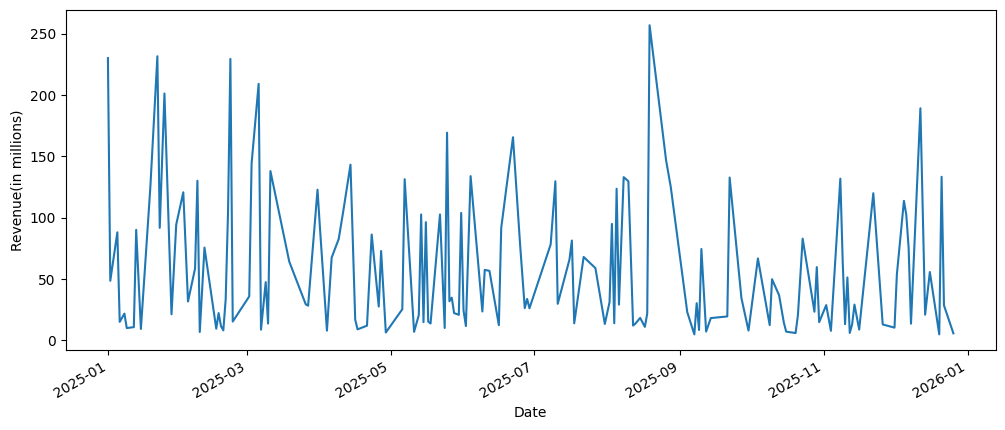

In [45]:
# Your code for Task 1 here
np.random.seed(42)
dates = pd.date_range(start="2025-01-01", end="2026-01-01", freq="D")
products = ["Cocoa", "Cashew", "Soya"]
regions = ["Ondo", "Ekiti", "Kogi", "Oyo", "Ogun", "Kano"]

datelist = []
productlist = []
quantitylist = []
pricelist = []
regionlist = []

for i in range(200):
    product = np.random.choice(products)
    
    if product == "Cocoa":
        region = np.random.choice(["Ondo", "Ekiti"])
        price = round(np.random.uniform(4.7, 5.0), 2)
    elif product == "Cashew":
        region = np.random.choice(["Kogi", "Oyo"])
        price = round(np.random.uniform(1.2, 1.4), 2)
    else:
        region = np.random.choice(["Ogun", "Kano"])
        price = round(np.random.uniform(0.45, 0.53), 2)
    
    datelist.append(np.random.choice(dates))
    productlist.append(product)
    quantitylist.append(np.random.randint(10, 30))
    pricelist.append(price)
    regionlist.append(region)
        

sales_data = pd.DataFrame(
    {
        "Date": datelist,
        "Product": productlist,
        "Quantity": quantitylist,
        "Price": pricelist,
        "Region": regionlist        
    }
)

sales_data["Revenue"] = sales_data["Quantity"] * sales_data["Price"]

# Total Revenue
revenuebyproduct = sales_data.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
revenuebyregion = sales_data.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
print(f"Revenue by; \n{revenuebyproduct}\n: \n{revenuebyregion}")

# Performance of products
best = revenuebyproduct.idxmax()
worst = revenuebyproduct.idxmin()
print(f"Best product: {best}\nWorst product: {worst}")

# Sales trend
daily_rev = sales_data.groupby("Date")["Revenue"].sum()
print(daily_rev)

plt.figure(figsize=(12, 5))
daily_rev.plot()
plt.xlabel("Date")
plt.ylabel("Revenue(in millions)")
plt.show()

# Growth rate
dailyrevgrowth = daily_rev.pct_change() * 100

# Focus more on cocoa
# Monitor trend regularly


---
## Task 2: Customer Behavior Analysis
Remove this cell if you're not completing this task.

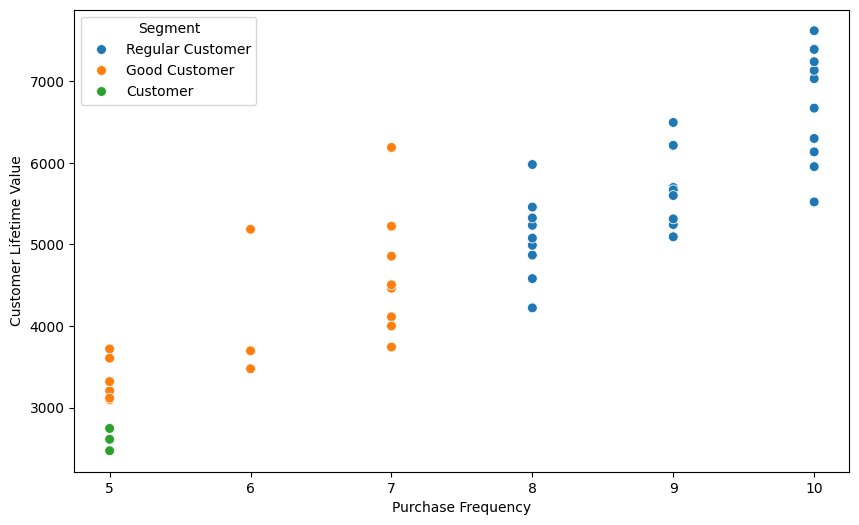

In [ ]:
# Your code for Task 2 here
np.random.seed(42)

customernum = 50
customerids = [f"CUS{cid}" for cid in np.random.choice(range(1200100, 1200199), customernum, replace=False)]

records = []
for customer in customerids:
    noofpurchases = np.random.randint(5, 11)
    
    for _ in range(noofpurchases):
        purchasedate = np.random.choice(pd.date_range(start="2025-01-01", end="2026-01-01", freq="D"))
        amountspent = round(np.random.uniform(300, 1000), 2)
        age = np.random.randint(18, 30)
        region = np.random.choice(["Lagos", "Abuja", "Rivers"])
        records.append([customer, purchasedate, amountspent, age, region])
    
customer_data = pd.DataFrame(records, columns=["CustomerID", "DateofPurchase", "AmountSpent", "Age", "Region"])

# Customer lifetime value
clv = (
    customer_data
    .groupby("CustomerID")["AmountSpent"]
    .sum()
    .reset_index()
    .rename(columns={"AmountSpent":"CLV"})    
       )
clv.head(10)

# Purchase frequency
purchasefreq = (
    customer_data
    .groupby("CustomerID")
    .size()
    .reset_index(name="PurchaseFrequency")
)
customer_summ = pd.merge(clv, purchasefreq, on="CustomerID")

# Customer segment
conditions = [
    (customer_summ["CLV"] > 4000)  & (customer_summ["PurchaseFrequency"] >= 8),
    (customer_summ["CLV"] > 3000),
    (customer_summ["PurchaseFrequency"] >= 8)
]

choices = [
    "Regular Customer",
    "Good Customer",
    "Once in a while Customer"
]

customer_summ["Segment"] = np.select(
    conditions,
    choices,
    default="Customer"
)

# Customer pattern
segment_analysis = (
    customer_summ
    .groupby("Segment")
    .agg(
        Avg_CLV=("CLV", "mean"),
        Avg_Frequency=("PurchaseFrequency", "mean"),
        Customer_Count=("CustomerID", "count")
    )
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=customer_summ,
    x="PurchaseFrequency",
    y="CLV",
    hue="Segment",
    s=50
)

plt.xlabel("Purchase Frequency")
plt.ylabel("Customer Lifetime Value")
plt.show()

# Customer Personas and Retention Strategies
# - Regular Customer
#       Spends a lot
#       Buys a lot
#           Retention strategies: VIP discount
# - Good Customer
#       Spends a lot
#       Buys sometimes
#           Retention strategies: Personalized offers
# - Once in a while Customer
#       Buys once in a while
#           Retention strategies: Discount bundles
# - Customer
#       Doesn't spend much
#       Doesn't buy much
#       Probably only bought from us once
#           Retention strategies: Promotions



---
## Task 3: Simple Statistical Analysis
Remove this cell if you're not completing this task.

In [ ]:
# Your code for Task 3 here


---
## Conclusion
Summarize your findings and any insights gained:

[Your conclusions here]